In [14]:
import os
import copy
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.models import (DenseNet121_Weights,  ResNet50_Weights,  ResNet101_Weights, EfficientNet_B0_Weights)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from preprocess_roi import preprocess_roi_from_uint16png

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, image_size=256):
        self.image_paths = image_paths
        self.labels = labels
        self.image_size = image_size
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        img = preprocess_roi_from_uint16png(img, size=self.image_size)

        img = torch.from_numpy(img).float().unsqueeze(0)
        img = img.repeat(3, 1, 1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)
        return img, label

In [4]:
train_dir = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\stage2_nodule_crops\DataSplit\test"

img_size = 128
batch_size = 16
num_workers = 0

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [5]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

train_paths = [s[0] for s in train_base.samples]
train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['benign', 'malignant']
Train: 7758
Val: 940
Test: 853


In [6]:
train_data = CTDataset(train_paths, train_labels, image_size=img_size)
val_data   = CTDataset(val_paths, val_labels, image_size=img_size)
test_data  = CTDataset(test_paths, test_labels, image_size=img_size)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [7]:
print(test_base.classes)

['benign', 'malignant']


## Soft voting

In [8]:
class WeightedSoftVotingEnsemble(nn.Module):
    def __init__(self, models, weights=None):
        super().__init__()

        self.models = nn.ModuleList(models)

        if weights is None:
            weights = [1.0] * len(models)

        weights = torch.tensor(weights, dtype=torch.float32)
        weights = weights / weights.sum()

        self.register_buffer("weights", weights)

        for model in self.models:
            model.eval()
            for p in model.parameters():
                p.requires_grad = False

    def forward(self, x):
        weighted_probs = torch.zeros(
            x.size(0),
            2,
            device=x.device
        )

        for model, weight in zip(self.models, self.weights):
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            weighted_probs += weight * probs

        return weighted_probs

In [9]:
resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Sequential(nn.Dropout(0.6), nn.Linear(resnet50.fc.in_features, num_classes))
resnet50.load_state_dict(torch.load("saved_models/resnet50diff_best_auc.pth", map_location=device))
resnet50.to(device)
resnet50.eval()

resnet101 = models.resnet101(weights=None)
resnet101.fc = nn.Sequential(nn.Dropout(0.6), nn.Linear(resnet101.fc.in_features, num_classes))
resnet101.load_state_dict(torch.load("saved_models/resnet101_best_sen.pth", map_location=device))
resnet101.to(device)
resnet101.eval()

densenet121 = models.densenet121(weights=None)
densenet121.classifier = nn.Sequential(nn.Dropout(0.6), nn.Linear(densenet121.classifier.in_features, num_classes))
densenet121.load_state_dict(torch.load("saved_models/densenet121_best_sen.pth",map_location=device))
densenet121.to(device)
densenet121.eval()

efficientnet = models.efficientnet_b0(weights=None)
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, num_classes))
efficientnet.load_state_dict(torch.load("saved_models/efficientnet_b0_best_sen.pth", map_location=device))
efficientnet.to(device)
efficientnet.eval()

C:\Users\rgzep\AppData\Local\Temp\ipykernel_17624\2638691768.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet50.load_state_dict(torch.load("saved_models/resnet50di

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch
import torch.nn.functional as F

def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)[:,1]

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    recall = recall_score(all_labels, all_preds)

    return acc, f1, auc, recall

In [11]:
def evaluate_ensemble(model, test_loader, device, class_names):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            probs = model(images)                 # weighted probabilities
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # probability of positive class
            all_probs.extend(probs[:, 1].cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
   
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(auc, 4))

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(report)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }

In [12]:
def predict_ensemble(model, image_tensor, class_names):
    model.eval()
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        probs = model(image_tensor)
        confidence, predicted_class = torch.max(probs, dim=1)

    return {
        "prediction": class_names[predicted_class.item()],
        "confidence": confidence.item(),
        "probabilities": probs.cpu().numpy()
    }

In [15]:
for name, model in [
    ("resnet50", resnet50),
    ("densenet121", densenet121),
    ("resnet101", resnet101),
    ("efficientnetb0", efficientnet)
]:
    acc, f1, auc, recall = evaluate(model, val_loader)
    print(name, acc, f1, auc, recall)

resnet50 0.7861702127659574 0.832639467110741 0.874662776523251 0.8143322475570033
densenet121 0.7797872340425532 0.8146821844225605 0.8651355888171699 0.741042345276873
resnet101 0.7797872340425532 0.8273561301084237 0.8609590136088408 0.8078175895765473
efficientnetb0 0.7021276595744681 0.7445255474452555 0.7632741152255151 0.6644951140065146


Accuracy : 0.7862
Precision: 0.7644
Recall   : 0.7737
F1 Score : 0.7683
ROC AUC  : 0.8747

Confusion Matrix:
[[239  87]
 [114 500]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.68      0.73      0.70       326
   malignant       0.85      0.81      0.83       614

    accuracy                           0.79       940
   macro avg       0.76      0.77      0.77       940
weighted avg       0.79      0.79      0.79       940



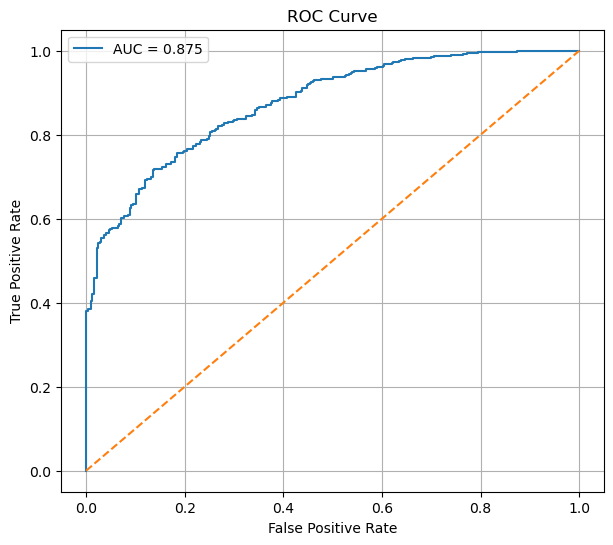

Accuracy : 0.8007
Precision: 0.7973
Recall   : 0.7983
F1 Score : 0.7978
ROC AUC  : 0.8639

Confusion Matrix:
[[290  82]
 [ 88 393]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.77      0.78      0.77       372
   malignant       0.83      0.82      0.82       481

    accuracy                           0.80       853
   macro avg       0.80      0.80      0.80       853
weighted avg       0.80      0.80      0.80       853



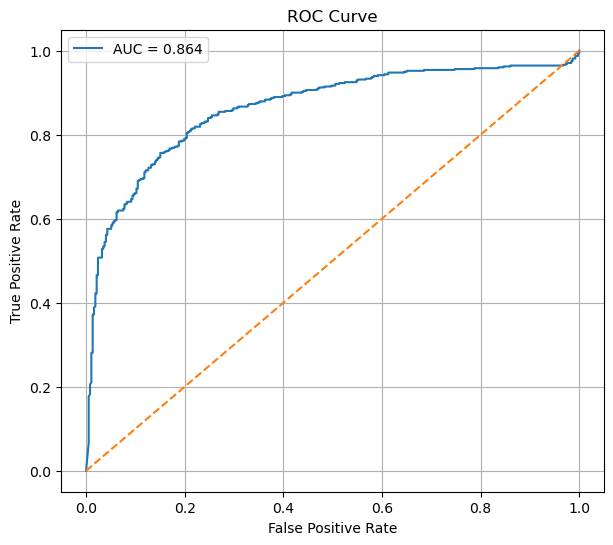

In [17]:
#Baseline only
weights=[1, 0, 0]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8096
Precision: 0.79
Recall   : 0.8053
F1 Score : 0.7957
ROC AUC  : 0.8916

Confusion Matrix:
[[258  68]
 [111 503]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.70      0.79      0.74       326
   malignant       0.88      0.82      0.85       614

    accuracy                           0.81       940
   macro avg       0.79      0.81      0.80       940
weighted avg       0.82      0.81      0.81       940



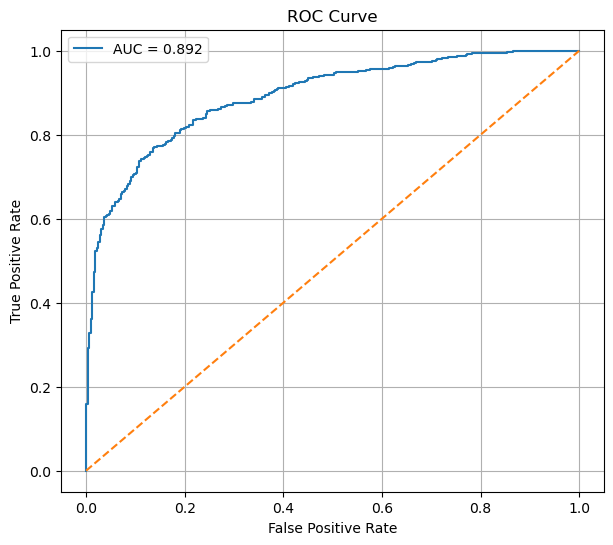

Accuracy : 0.7984
Precision: 0.795
Recall   : 0.7974
F1 Score : 0.7959
ROC AUC  : 0.8721

Confusion Matrix:
[[294  78]
 [ 94 387]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.76      0.79      0.77       372
   malignant       0.83      0.80      0.82       481

    accuracy                           0.80       853
   macro avg       0.79      0.80      0.80       853
weighted avg       0.80      0.80      0.80       853



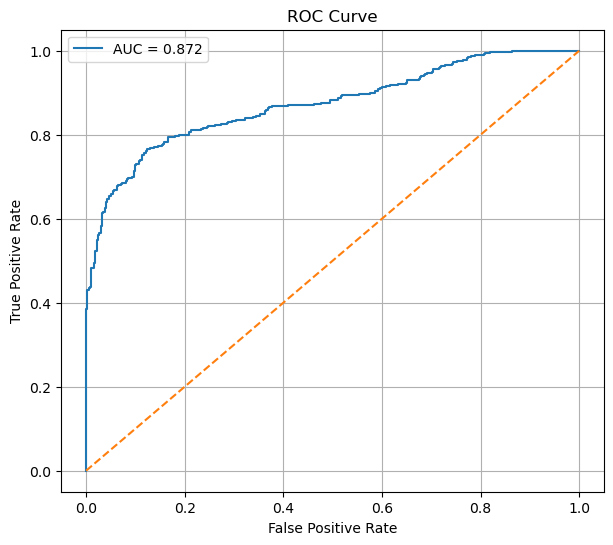

In [16]:
#Equal weights
weights=[1, 1, 1]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8117
Precision: 0.7922
Recall   : 0.8069
F1 Score : 0.7977
ROC AUC  : 0.8916

Confusion Matrix:
[[258  68]
 [109 505]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.70      0.79      0.74       326
   malignant       0.88      0.82      0.85       614

    accuracy                           0.81       940
   macro avg       0.79      0.81      0.80       940
weighted avg       0.82      0.81      0.81       940



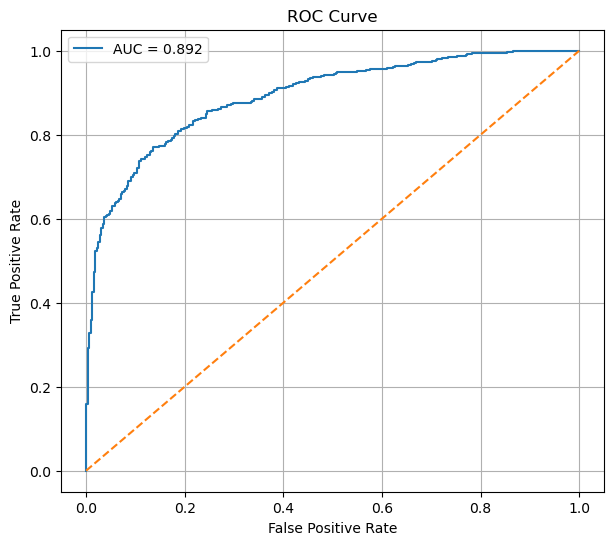

Accuracy : 0.7984
Precision: 0.795
Recall   : 0.7974
F1 Score : 0.7959
ROC AUC  : 0.8722

Confusion Matrix:
[[294  78]
 [ 94 387]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.76      0.79      0.77       372
   malignant       0.83      0.80      0.82       481

    accuracy                           0.80       853
   macro avg       0.79      0.80      0.80       853
weighted avg       0.80      0.80      0.80       853



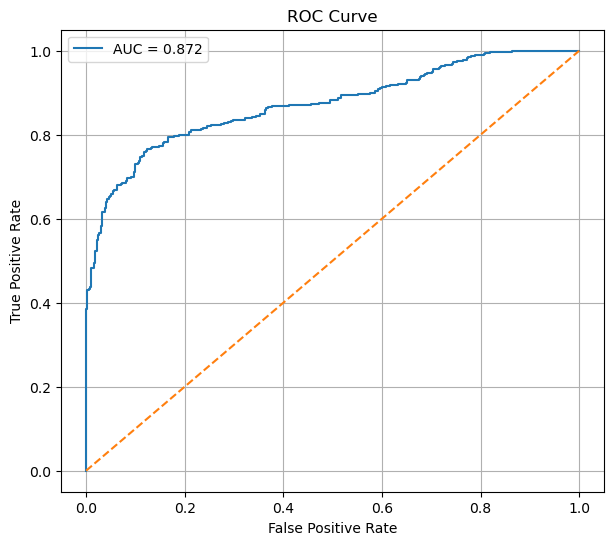

In [18]:
#AUC weights
weights=[0.874662776523251, 0.8651355888171699, 0.8609590136088408]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101, efficientnet],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8096
Precision: 0.79
Recall   : 0.8053
F1 Score : 0.7957
ROC AUC  : 0.8916

Confusion Matrix:
[[258  68]
 [111 503]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.70      0.79      0.74       326
   malignant       0.88      0.82      0.85       614

    accuracy                           0.81       940
   macro avg       0.79      0.81      0.80       940
weighted avg       0.82      0.81      0.81       940



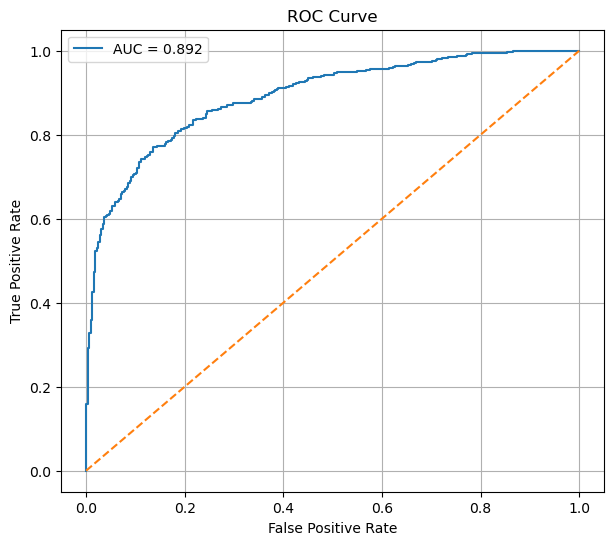

Accuracy : 0.7995
Precision: 0.7962
Recall   : 0.7985
F1 Score : 0.7971
ROC AUC  : 0.8722

Confusion Matrix:
[[294  78]
 [ 93 388]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.76      0.79      0.77       372
   malignant       0.83      0.81      0.82       481

    accuracy                           0.80       853
   macro avg       0.80      0.80      0.80       853
weighted avg       0.80      0.80      0.80       853



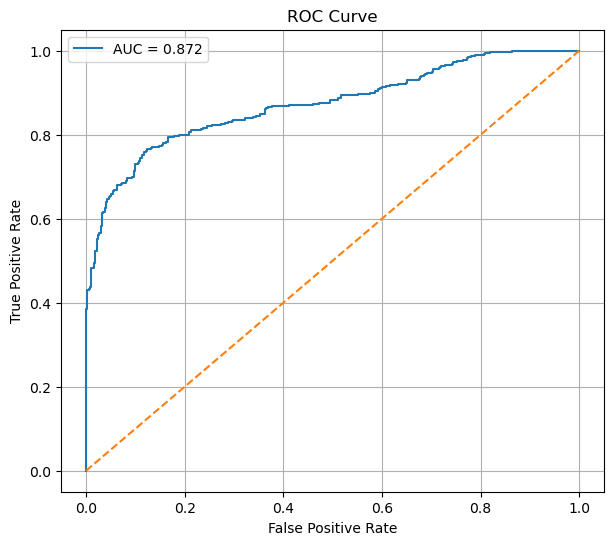

In [19]:
#Acc weights
weights = [0.7861702127659574, 0.7797872340425532, 0.7797872340425532]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8074
Precision: 0.7877
Recall   : 0.8022
F1 Score : 0.7932
ROC AUC  : 0.891

Confusion Matrix:
[[256  70]
 [111 503]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.70      0.79      0.74       326
   malignant       0.88      0.82      0.85       614

    accuracy                           0.81       940
   macro avg       0.79      0.80      0.79       940
weighted avg       0.82      0.81      0.81       940



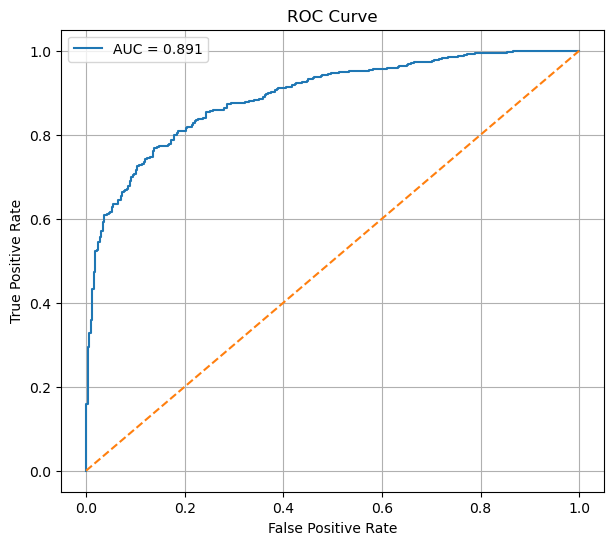

Accuracy : 0.8007
Precision: 0.7973
Recall   : 0.7995
F1 Score : 0.7982
ROC AUC  : 0.8723

Confusion Matrix:
[[294  78]
 [ 92 389]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.76      0.79      0.78       372
   malignant       0.83      0.81      0.82       481

    accuracy                           0.80       853
   macro avg       0.80      0.80      0.80       853
weighted avg       0.80      0.80      0.80       853



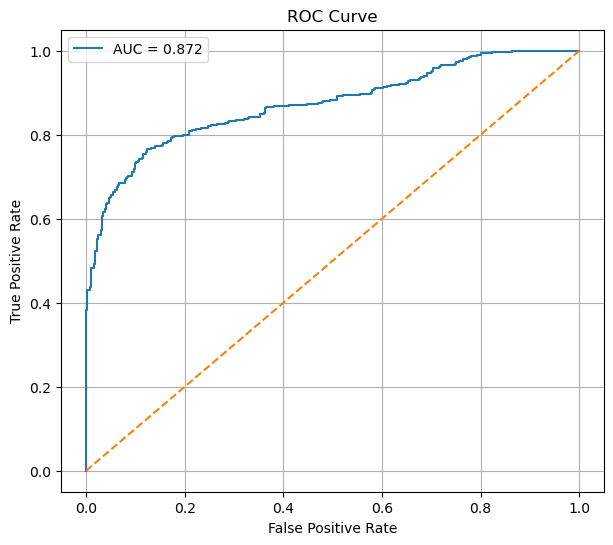

In [20]:
#sensitivity
weights = [0.8143322475570033, 0.741042345276873, 0.8078175895765473]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8096
Precision: 0.79
Recall   : 0.8053
F1 Score : 0.7957
ROC AUC  : 0.8916

Confusion Matrix:
[[258  68]
 [111 503]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.70      0.79      0.74       326
   malignant       0.88      0.82      0.85       614

    accuracy                           0.81       940
   macro avg       0.79      0.81      0.80       940
weighted avg       0.82      0.81      0.81       940



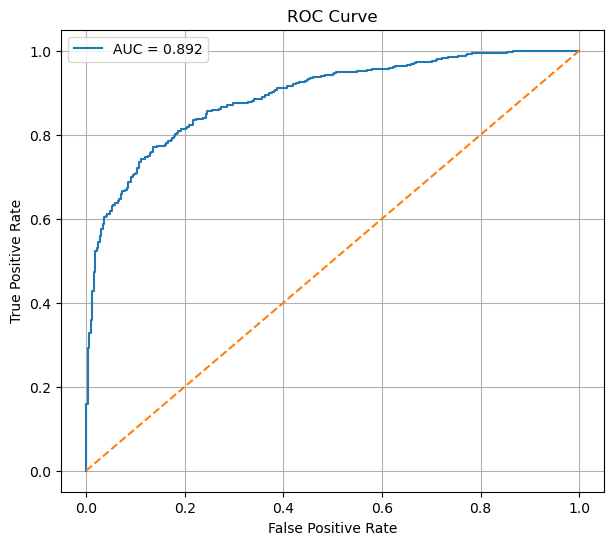

Accuracy : 0.7995
Precision: 0.7962
Recall   : 0.7985
F1 Score : 0.7971
ROC AUC  : 0.8722

Confusion Matrix:
[[294  78]
 [ 93 388]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.76      0.79      0.77       372
   malignant       0.83      0.81      0.82       481

    accuracy                           0.80       853
   macro avg       0.80      0.80      0.80       853
weighted avg       0.80      0.80      0.80       853



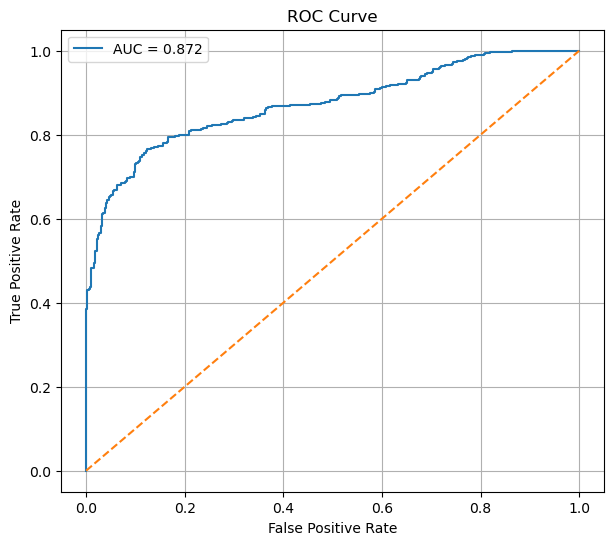

In [21]:
#f1
weights = [0.832639467110741, 0.8146821844225605, 0.8273561301084237]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

# Tuning (3 models)

In [22]:
models_list = [resnet50, densenet121, resnet101]

for m in models_list:
    m.eval()
    for p in m.parameters():
        p.requires_grad = False

In [23]:
def get_model_probs(models_list, loader, device):
    all_model_probs = [[] for _ in models_list]
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            for i, model in enumerate(models_list):
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                all_model_probs[i].append(probs.cpu().numpy())

            all_labels.append(labels.numpy())

    all_model_probs = [
        np.concatenate(p, axis=0)
        for p in all_model_probs
    ]

    all_labels = np.concatenate(all_labels)

    return all_model_probs, all_labels

In [24]:
def evaluate_probs(y_true, probs, class_names):
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, probs[:, 1])
    malignant_recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(auc, 4))
    print("Malignant Recall:", round(malignant_recall, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "malignant_recall": malignant_recall
    }

In [25]:
val_probs, y_val = get_model_probs(models_list, val_loader, device)
test_probs, y_test = get_model_probs(models_list, test_loader, device)

In [26]:
best = {
    "weights": None,
    "f1": -1,
    "auc": -1,
    "recall": -1
}

step = 0.01

for w1 in np.arange(0, 1.0001, step):
    for w2 in np.arange(0, 1.0001 - w1, step):
        w3 = 1.0 - w1 - w2

        if w3 < 0:
            continue

        weights = np.array([w1, w2, w3])

        ensemble_val_probs = (
            weights[0] * val_probs[0] +
            weights[1] * val_probs[1] +
            weights[2] * val_probs[2]
        )

        y_pred = np.argmax(ensemble_val_probs, axis=1)

        f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        auc = roc_auc_score(y_val, ensemble_val_probs[:, 1])
        recall = recall_score(y_val, y_pred, average="macro", zero_division=0)
        malignant_recall = recall_score(y_val, y_pred, pos_label=1, zero_division=0)

        # tuning based on macro recall
        if recall > best["recall"]:
            best = {
                "weights": weights,
                "f1": f1,
                "auc": auc,
                "malignant_recall": malignant_recall,
                "recall": recall
            }

print("Best validation weights:")
print("ResNet50   :", round(best["weights"][0], 2))
print("DenseNet121:", round(best["weights"][1], 2))
print("ResNet101  :", round(best["weights"][2], 2))

print("\nBest validation scores:")
print("F1:", round(best["f1"], 4))
print("AUC:", round(best["auc"], 4))
print("Recall:", round(best["recall"], 4))
print("Malig recall:", round(best["malignant_recall"], 4))

Best validation weights:
ResNet50   : 0.22
DenseNet121: 0.62
ResNet101  : 0.16

Best validation scores:
F1: 0.8064
AUC: 0.8938
Recall: 0.8253
Malig recall: 0.7948


In [27]:
best_weights = best["weights"]

ensemble_test_probs = (
    best_weights[0] * test_probs[0] +
    best_weights[1] * test_probs[1] +
    best_weights[2] * test_probs[2]
)

print("Final Tuned Ensemble Test Results")
test_metrics = evaluate_probs(y_test, ensemble_test_probs, class_names)

Final Tuned Ensemble Test Results
Accuracy : 0.7773
Precision: 0.7781
Recall   : 0.7827
F1 Score : 0.7765
ROC AUC  : 0.8625
Malignant Recall: 0.7401

Confusion Matrix:
[[307  65]
 [125 356]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.71      0.83      0.76       372
   malignant       0.85      0.74      0.79       481

    accuracy                           0.78       853
   macro avg       0.78      0.78      0.78       853
weighted avg       0.79      0.78      0.78       853



## 2 model combo

Accuracy : 0.8032
Precision: 0.7838
Recall   : 0.8004
F1 Score : 0.7896
ROC AUC  : 0.8866

Confusion Matrix:
[[258  68]
 [117 497]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.69      0.79      0.74       326
   malignant       0.88      0.81      0.84       614

    accuracy                           0.80       940
   macro avg       0.78      0.80      0.79       940
weighted avg       0.81      0.80      0.81       940



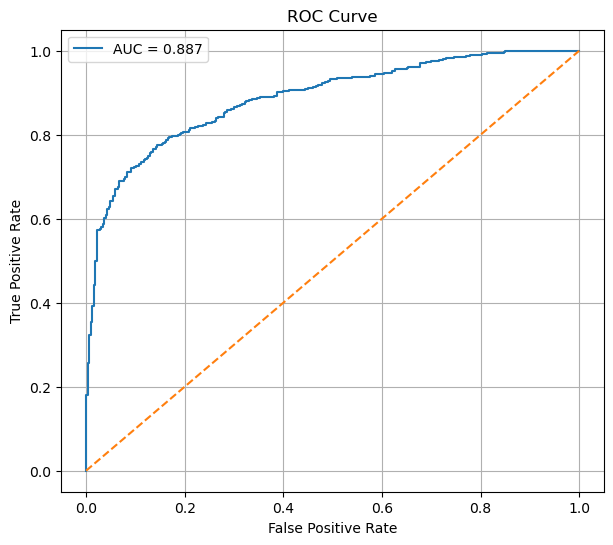

Accuracy : 0.7948
Precision: 0.7919
Recall   : 0.7955
F1 Score : 0.7929
ROC AUC  : 0.8719

Confusion Matrix:
[[298  74]
 [101 380]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.75      0.80      0.77       372
   malignant       0.84      0.79      0.81       481

    accuracy                           0.79       853
   macro avg       0.79      0.80      0.79       853
weighted avg       0.80      0.79      0.80       853



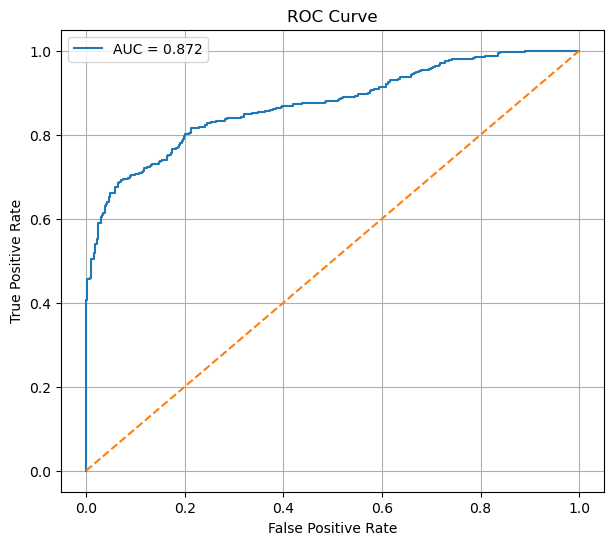

In [29]:
weights=[1, 1]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.7936
Precision: 0.7723
Recall   : 0.7809
F1 Score : 0.7759
ROC AUC  : 0.8769

Confusion Matrix:
[[241  85]
 [109 505]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.69      0.74      0.71       326
   malignant       0.86      0.82      0.84       614

    accuracy                           0.79       940
   macro avg       0.77      0.78      0.78       940
weighted avg       0.80      0.79      0.80       940



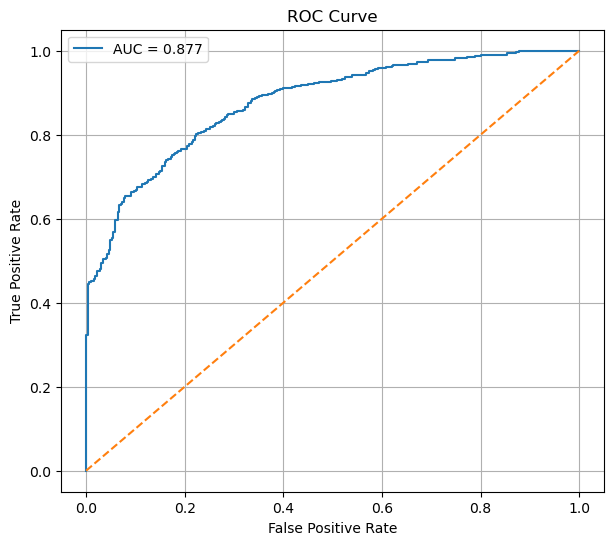

Accuracy : 0.7819
Precision: 0.7788
Recall   : 0.7765
F1 Score : 0.7775
ROC AUC  : 0.8597

Confusion Matrix:
[[273  99]
 [ 87 394]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.76      0.73      0.75       372
   malignant       0.80      0.82      0.81       481

    accuracy                           0.78       853
   macro avg       0.78      0.78      0.78       853
weighted avg       0.78      0.78      0.78       853



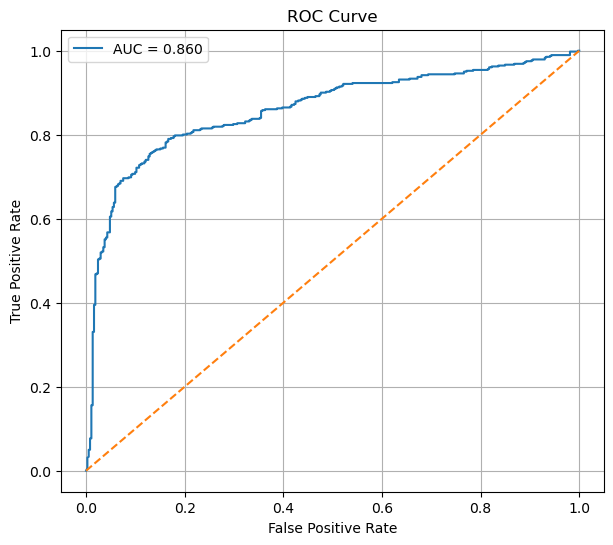

In [30]:
weights=[1, 1]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

# Tuning

In [31]:
def get_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_probs), np.concatenate(all_labels)

In [32]:
resnet_val_probs, y_val = get_probs(resnet50, val_loader, device)
dense_val_probs, _ = get_probs(densenet121, val_loader, device)

In [33]:
best = {"weights": None, "threshold": None, "recall": -1}

for w1 in np.arange(0.40, 0.60, 0.005):
    w2 = 1 - w1

    probs = w1 * resnet_val_probs + w2 * dense_val_probs

    for t in np.arange(0.4, 0.6, 0.05):
        y_pred = (probs[:, 1] >= t).astype(int)

        recall = recall_score(y_val, y_pred, average="macro", zero_division=0)

        if recall > best["recall"]:
            best = {
                "weights": [w1, w2],
                "threshold": t,
                "recall": recall
            }

print(best)

{'weights': [0.45500000000000007, 0.5449999999999999], 'threshold': 0.55, 'recall': 0.8179792570092524}


Accuracy : 0.8117
Precision: 0.7932
Recall   : 0.812
F1 Score : 0.7994
ROC AUC  : 0.8872

Confusion Matrix:
[[265  61]
 [116 498]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.70      0.81      0.75       326
   malignant       0.89      0.81      0.85       614

    accuracy                           0.81       940
   macro avg       0.79      0.81      0.80       940
weighted avg       0.82      0.81      0.81       940



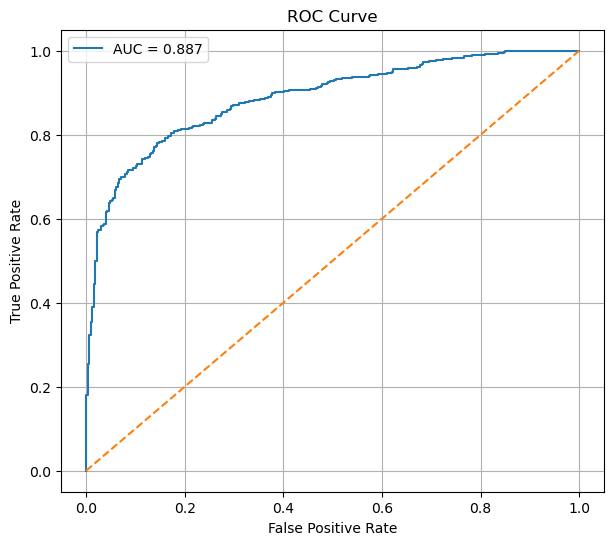

Accuracy : 0.7819
Precision: 0.7808
Recall   : 0.7853
F1 Score : 0.7808
ROC AUC  : 0.8704

Confusion Matrix:
[[302  70]
 [116 365]]

Classification Report:
              precision    recall  f1-score   support

      benign       0.72      0.81      0.76       372
   malignant       0.84      0.76      0.80       481

    accuracy                           0.78       853
   macro avg       0.78      0.79      0.78       853
weighted avg       0.79      0.78      0.78       853



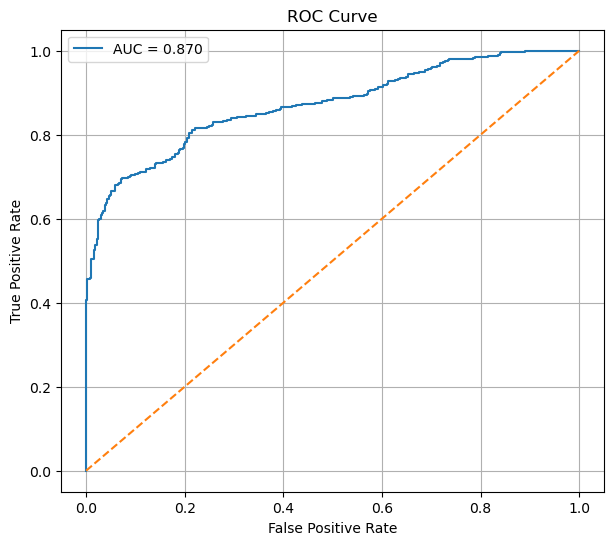

In [34]:
weights=best["weights"]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

## Logistic Regression

In [35]:
def collect_model_probs(models, loader):
    X_meta = []
    y_meta = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            batch_probs = []
            for model in models:
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                batch_probs.append(probs.cpu().numpy())

            batch_features = np.concatenate(batch_probs, axis=1)
            X_meta.append(batch_features)
            y_meta.append(labels.numpy())

    return np.vstack(X_meta), np.concatenate(y_meta)

In [36]:
models = [resnet50, densenet121, resnet101]

for model in models:
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

In [37]:
X_val, y_val = collect_model_probs(models, val_loader)
X_test, y_test = collect_model_probs(models, test_loader)

In [38]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_val, y_val)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
test_preds = meta_model.predict(X_test)
test_probs = meta_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, average="macro", zero_division=0))
print("Recall   :", recall_score(y_test, test_preds, average="macro", zero_division=0))
print("F1 Score :", f1_score(y_test, test_preds, average="macro", zero_division=0))
print("AUC:", roc_auc_score(y_test, test_probs))
print(confusion_matrix(y_test, test_preds))

Accuracy: 0.772567409144197
Precision: 0.7703231370219765
Recall   : 0.764527865334317
F1 Score : 0.7665453416850065
AUC: 0.8652169539266314
[[261 111]
 [ 83 398]]
